# **Final Notebook: Baseline Global Feature Model**

In [98]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.global_feature_extractor import SurgicalFeatureExtractor
from src_final.models.analysis import leakage_free_correlation_analysis, leakage_free_residual_analysis
from src_final.models.baseline_loso import evaluate_loso_model

In [99]:
# file paths
processed_dir="data/processed/landmark_dataframes2/" # NOTE the original results were obtained with "landmark_dataframes"
ratings_csv="data/scores/merged_scores.csv"

# create scores dataframe
df_ratings = pd.read_csv(ratings_csv)

# create all metrics dataframe
end = "_30fps_processed.pkl"
processed_files = sorted([f for f in os.listdir(processed_dir) if f.endswith(end)])
all_metrics = []

for filename in tqdm(processed_files):
    # Load raw tracking data
    df_raw = pd.read_pickle(os.path.join(processed_dir, filename))
    
    # Initialize and compute in one step
    extractor = SurgicalFeatureExtractor(df_raw, fps=30, min_disp=0, vel_threshold=40)
    
    # Get the 1-row dataframe of features
    feats = extractor.features_df
    feats["file"] = filename.replace('hand_tracking_', '').replace(end, '') # Add identifier
    
    all_metrics.append(feats)

# Combine all videos
df_all_metrics = pd.concat(all_metrics, ignore_index=True)

# Merge with scores (as you did before)
df_full = pd.merge(df_all_metrics, df_ratings, left_on="file", right_on="Vid_Name").drop(columns=["file"])

100%|██████████| 88/88 [00:21<00:00,  4.18it/s]


In [100]:
# remove a participant for reason to verify
df_full = df_full[df_full["Participant Number"] != 8]

## Use top Features Only
Extract features that are highly correlated with scores (>0.6) over all folds

In [101]:
# correlation between features and scores
all_features = [col for col in df_full if col not in df_ratings.columns]
right_features = [col for col in all_features if 'Left' not in col]
fair_corr_df = leakage_free_correlation_analysis(df_full, all_features, n=6)
fair_corr_df

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 39.13it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
18,num_reversals_Right,-0.718384,0.011447,-0.752266,-0.705991,1.000000
31,total_duration_Left,-0.684729,0.011293,-0.714053,-0.666340,1.000000
32,total_duration_Right,-0.684197,0.011335,-0.713487,-0.665757,1.000000
16,nmu_peaks_Right,-0.678805,0.013019,-0.715874,-0.660553,1.000000
34,total_path_Right,-0.669737,0.014455,-0.708289,-0.651589,1.000000
8,ldlj_smoothness_Left,0.638477,0.015777,0.610076,0.688787,0.785714
17,num_reversals_Left,-0.628779,0.014508,-0.656598,-0.592668,0.142857
15,nmu_peaks_Left,-0.624045,0.013900,-0.645851,-0.596150,0.035714
30,total_angular_path_Right,-0.617772,0.012846,-0.646559,-0.601990,0.035714
9,ldlj_smoothness_Right,0.616430,0.011857,0.591682,0.639987,0.000000


In [102]:
top_features = fair_corr_df[(abs(fair_corr_df['Min_Corr_with_Target']) > 0.6) & (abs(fair_corr_df['Max_Corr_with_Target']) > 0.6)]['Feature'].tolist()

# top feature intercorrelation
inter_corrs = df_full[top_features].corr()

# if over 97.5% correlated, drop second feature
to_drop = set()
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        feat1 = top_features[i]
        feat2 = top_features[j]
        if abs(inter_corrs.loc[feat1, feat2]) > 0.975:
            to_drop.add(feat2)

to_drop

{'total_duration_Right'}

In [103]:
top_features = [feat for feat in top_features if feat not in to_drop]

# Try Some Models with these Features
- using all features
- using only the top correlated features

LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 52.13it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7014 | MAE: 5.3340 | MAE STD: 4.1589 | R2: 0.4720 | Adj R2: 0.4227

Feature Weights:
                    Feature  Average_Weight  Std_Weight
0                      bias       50.373011    0.359169
1       num_reversals_Right       -2.269833    0.123354
2       total_duration_Left       -1.847751    0.208078
3           nmu_peaks_Right       -0.221502    0.188771
4          total_path_Right       -1.466821    0.182863
5      ldlj_smoothness_Left        1.500634    0.215292
6  total_angular_path_Right       -0.061307    0.224675

--- Per-Fold Performance Summary ---


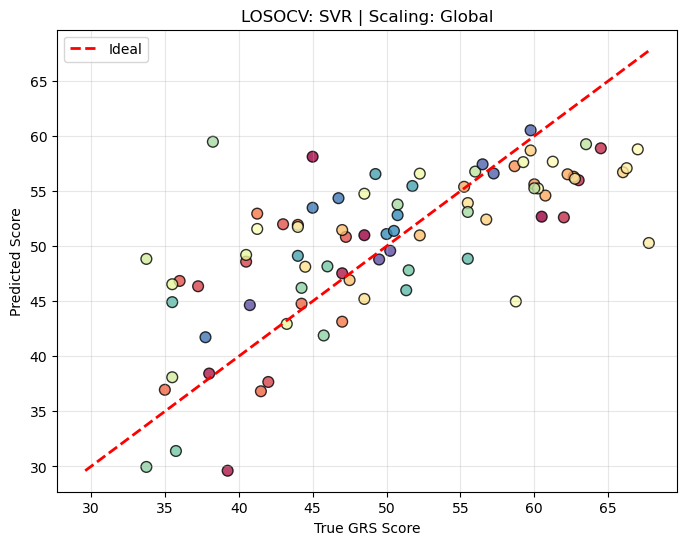

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 87.75it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7148 | MAE: 5.3033 | MAE STD: 4.0791 | R2: 0.4833 | Adj R2: 0.4704

Feature Weights:
               Feature  Average_Weight  Std_Weight
0                 bias       49.938586    0.302804
1  num_reversals_Right       -6.683252    0.161086

--- Per-Fold Performance Summary ---


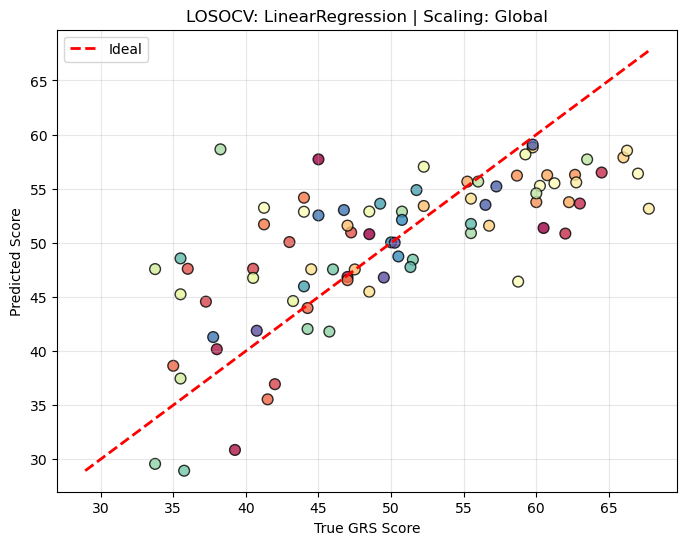

In [104]:
# Ridge
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
_, _, _ = evaluate_loso_model(df_full, top_features, model_class=SVR, model_params={'kernel':'linear', 'C':0.5, 'epsilon':0.1})
_, _, _ = evaluate_loso_model(df_full, ['num_reversals_Right'], model_class=LinearRegression, model_params={})

# All Top Features are Highly Inter-Correlated
- Remove very redundant ones > 97.5% corr
- PCA with the remaining ones

In [105]:
# keep first
top_features = [feat for feat in top_features if feat not in to_drop]


scaler = StandardScaler()
X = scaler.fit_transform(df_all_metrics[top_features].values)

pca = PCA(n_components=len(top_features))
pca.fit(X)
components = pca.components_
explained_variance = pca.explained_variance_ratio_

df = pd.DataFrame(components, columns=top_features)
df['Explained_Variance'] = explained_variance
df

,num_reversals_Right,total_duration_Left,nmu_peaks_Right,total_path_Right,ldlj_smoothness_Left,total_angular_path_Right,Explained_Variance
0,0.426805,0.411557,0.425151,0.419110,-0.368532,0.395266,0.874586
1,0.208629,-0.161190,0.215418,0.284511,0.868926,0.219335,0.060324
2,-0.204454,-0.347145,-0.162381,-0.212526,-0.124174,0.866449,0.035021
3,-0.107628,0.807882,-0.212179,-0.393918,0.305376,0.205662,0.019254
4,-0.230493,0.133694,-0.649476,0.710319,-0.004314,0.051070,0.006810
5,0.817190,-0.116539,-0.528806,-0.196235,-0.021424,-0.004168,0.004006


In [106]:
top_features

['num_reversals_Right',
 'total_duration_Left',
 'nmu_peaks_Right',
 'total_path_Right',
 'ldlj_smoothness_Left',
 'total_angular_path_Right']

## Model With PCA features

LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 46.56it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7092 | MAE: 5.2684 | MAE STD: 4.0713 | R2: 0.4883 | Adj R2: 0.4755

Feature Weights:
  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.302804
1     PC1       -2.879630    0.068227

--- Per-Fold Performance Summary ---


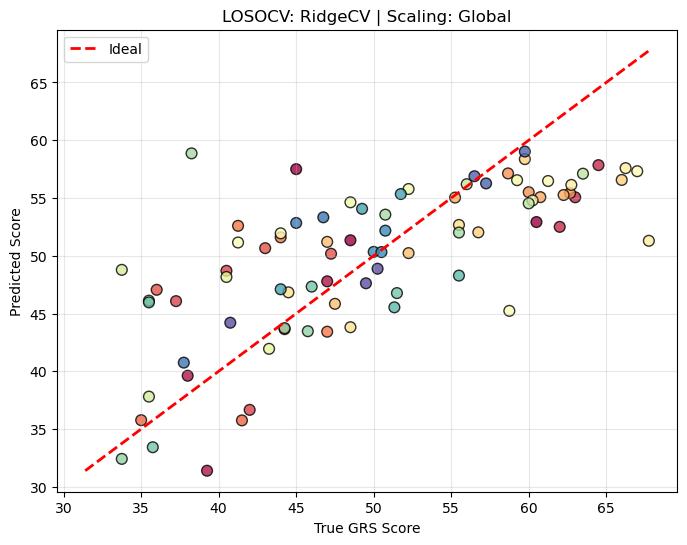

In [107]:
_, _, _ = evaluate_loso_model(df_full, top_features, model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

## How Well Do the Remaining Features Explain the Residuals of PC1 Model?

In [109]:
candidate_features = [feat for feat in all_features if feat not in top_features]
#candidate_features.remove('velocity_ratio')
df_res_leakage_free = leakage_free_residual_analysis(df_full, top_features, candidate_features, top_n=1, test_other_pcs=True)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  8.29it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
34,velocity_corr,0.120289,0.017269,5.707816e-02,-0.330664,1.0
4,PCA_Comp_6,0.045505,0.007775,2.334538e-02,-0.216257,0.0
35,velocity_ratio,0.042313,0.011263,1.577755e-02,-0.203416,0.0
22,orientation_entropy_Right,0.021128,0.005764,7.723845e-03,-0.141825,0.0
23,pose_variability_Left,0.019426,0.006826,4.314988e-03,-0.129295,0.0
29,stationary_time_ratio_Left,0.015920,0.006145,5.831144e-03,0.119162,0.0
25,rms_accel_Left,0.015198,0.005055,7.074388e-04,-0.115454,0.0
20,num_reversals_Left,0.012642,0.005476,6.048274e-04,-0.064697,0.0
7,fraction_tracked_Left,0.012230,0.004766,3.150345e-03,0.103182,0.0
27,rotation_over_dist_Left,0.011707,0.006659,2.458595e-03,-0.104610,0.0


### Hybrid Model PC1 + Velocity Corr

Significant imporvement!

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 83.55it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7560 | MAE: 5.1521 | MAE STD: 3.8107 | R2: 0.5260 | Adj R2: 0.5080

Feature Weights:
         Feature  Average_Weight  Std_Weight
0           bias       49.938586    0.302804
1            PC1       -7.309834    0.165582
2  velocity_corr       -2.317598    0.183573

--- Per-Fold Performance Summary ---
    Train_MAE  Test_MAE  Test_Corr
1    4.656528  8.581108  -0.818292
2    4.830207  3.830954   0.809304
3    4.771230  7.360131   0.977778
4    4.750781  6.631123  -0.315532
5    4.720657  7.497660   0.979694
6    4.939004  1.637941   0.905121
7    4.715235  7.147109  -0.604180
9    4.810600  5.720886  -0.695378
10   4.818890  5.463291  -0.355042
11   4.932343  1.635465   0.659421
12   4.827906  5.419209   0.433489
13   4.913197  2.248487   0.971042
14   4.839638  5.891831   0.541466
15   4.789737  6.784912   0.016714
16   4.653760  9.062516  -0.889158
17   4.927527  1.721271   0.999978
18   4.893619  3.191109   0.988802
19   4.782845  6.7849

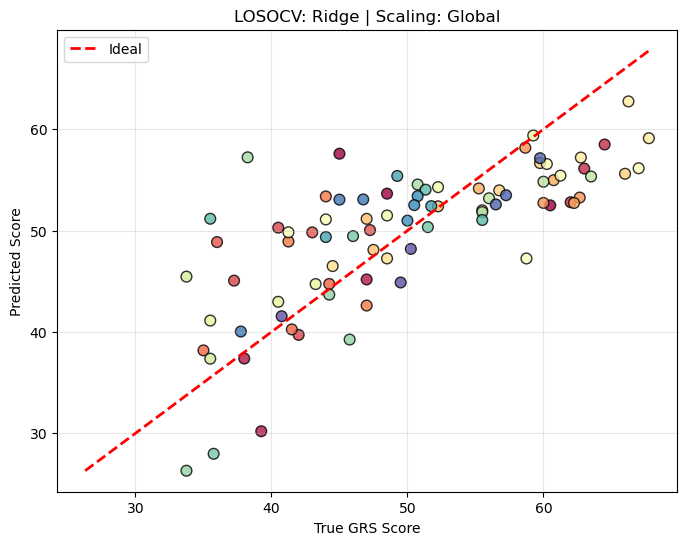

In [110]:
_, _, _ = evaluate_loso_model(df_full, ['num_reversals_Right'], extra_features=['velocity_corr'], model_class=Ridge, pca_components=[0], print_fold_metrics=True)

**Interpretation negative velocity correlation weight**

The Novice (High Correlation): Often moves both hands in a "mirroring" or "coupled" fashion because they lack the independent motor control to perform different tasks with each hand. When they move the right hand to pull a thread, the left hand "sympathetically" moves or trembles in the same direction.

The Expert (Lower Correlation): Experts exhibit bimanual functional dissociation. One hand is perfectly still (providing counter-traction) while the other hand moves at high speed. Or, one hand moves left while the other moves up. Their velocity profiles are uncoupled because their hands have specialized roles.

## Statistical Significance?

In [23]:
all_shuffled_r2 = []
all_shuffled_vel_corr_r2 = []
for seed in range(400):
    df_res = leakage_free_residual_analysis(df_full, top_features, candidate_features, top_n=1, perform_shuffle=True, seed=seed)
    top_3_r2 = df_res['Shuffled_R2_mean'].values[:3]
    vel_corr_r2 = df_res[df_res['Feature']=='velocity_corr']['Shuffled_R2_mean'].values[0]
    all_shuffled_vel_corr_r2.append(vel_corr_r2)
    print(f"Seed {seed}: Top 3 R2: {top_3_r2}")
    for r2 in top_3_r2:
        all_shuffled_r2.append(r2)

# !! next: run with selection stability !!

Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  6.35it/s]


Seed 0: Top 3 R2: [0.07732843 0.06321471 0.054702  ]


Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  5.79it/s]


Seed 1: Top 3 R2: [0.06159338 0.05194117 0.04793141]


Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  6.35it/s]


...

Seed 397: Top 3 R2: [0.05131756 0.05128812 0.04135974]


Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  7.83it/s]


Seed 398: Top 3 R2: [0.03293094 0.02718786 0.02679384]


Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  7.53it/s]

Seed 399: Top 3 R2: [0.10735669 0.10495114 0.08096095]


Empirical p-value: 0.102
Z-score vs Null: 1.44


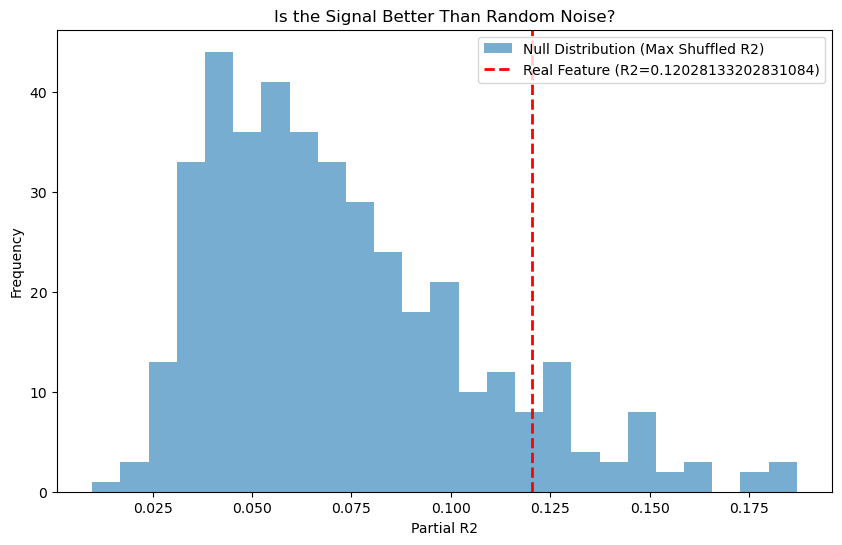

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
        
# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = df_res_leakage_free['Partial_R2_mean'].values[0]

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2[::3] # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Take Different Cases into account

- With Dummy Case variable
- By standarizing the relevant features by case

In [11]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_full['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_full.columns):
    df_full = pd.concat([df_full, df_case_onehot], axis=1)

In [25]:
candidate_features = list(set(candidate_features + list(df_case_onehot.columns)))
df_res_leakage_free = leakage_free_residual_analysis(df_full, top_features, candidate_features, base_features=['Case_1', 'Case_2', 'Case_3'], top_n=1, test_other_pcs=False)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  8.14it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
32,velocity_corr,0.076894,0.014872,2.339183e-02,-0.238704,0.928571
13,mean_abs_angle_change_Right,0.045310,0.014416,2.155654e-02,-0.154839,0.035714
12,mean_abs_angle_change_Left,0.036892,0.007971,1.082620e-02,-0.174579,0.000000
20,orientation_entropy_Right,0.034938,0.007374,1.861508e-02,-0.164892,0.000000
15,mean_velocity_Right,0.034062,0.009602,1.255070e-02,-0.133188,0.000000
30,total_duration_Right,0.030313,0.006204,2.037150e-02,0.047192,0.000000
23,rms_accel_Left,0.029731,0.007664,6.649431e-03,-0.159137,0.000000
27,stationary_time_ratio_Left,0.027968,0.009298,1.307097e-02,0.140893,0.000000
16,movement_overlap_ratio,0.020931,0.008231,2.502310e-03,-0.132467,0.000000
5,fraction_tracked_Left,0.019725,0.005436,8.504676e-03,0.118213,0.000000


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 55.73it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7606 | MAE: 4.9918 | MAE STD: 3.8753 | R2: 0.5391 | Adj R2: 0.5027

Feature Weights:
         Feature  Average_Weight  Std_Weight
0           bias       49.955133    0.301969
1            PC1       -3.083958    0.070309
2  velocity_corr       -1.752152    0.182033
3         Case_1       -1.290034    0.086487
4         Case_2       -0.079743    0.135408
5         Case_3        1.369777    0.127541

--- Per-Fold Performance Summary ---


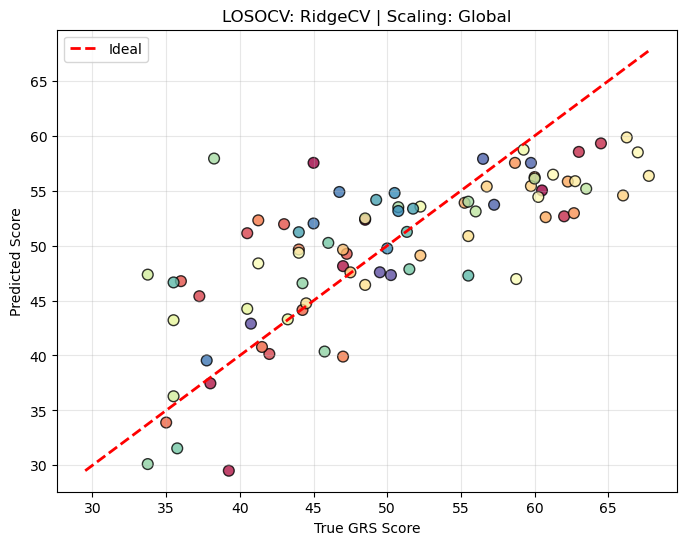

In [38]:
_, _, _ = evaluate_loso_model(df_full, top_features, extra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3'], model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0])

### Standarize by Case

While case-wise standardization is theoretically ideal for removing task-confounds, the limited sample size per task (N=27) likely introduces instability in the feature distributions. A Dummy Variable approach was adopted instead, as it allowed the model to account for baseline shifts in task difficulty (intercept) while maintaining the stability of the global kinematic distributions (slopes).


In [40]:
df_full[all_features].describe()

,total_path_Left,total_duration_Left,mean_velocity_Left,rms_accel_Left,ldlj_smoothness_Left,nmu_peaks_Left,efficiency_Left,mean_abs_angle_change_Left,stationary_time_ratio_Left,workspace_area_Left,...,pose_variability_Right,rotation_over_dist_Right,fraction_tracked_Right,velocity_corr,interhand_dist_mean,interhand_dist_std,interhand_dist_cv,interhand_dist_change_rms,movement_overlap_ratio,velocity_ratio
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,8.300000e+01,...,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,50105.843412,564.619277,112.023257,1363.874365,-24.486151,589.433735,91.173296,0.159244,0.445301,6.362876e+05,...,0.941762,0.006572,0.792257,0.468253,377.276115,105.664066,0.282008,17.157742,0.259714,0.684139
std,15995.980491,210.516022,21.442279,291.824357,0.800839,223.074536,15.413501,0.025744,0.103372,1.820303e+05,...,0.149338,0.001479,0.064036,0.098990,36.583743,16.999801,0.048775,3.775723,0.062980,0.151460
min,18500.202319,288.000000,62.318805,776.888552,-26.288729,247.000000,57.181750,0.104335,0.236850,3.786620e+05,...,0.639699,0.003783,0.541457,0.169612,290.269750,73.672155,0.198122,10.138496,0.137096,0.367484
25%,39114.848906,409.633333,98.917700,1193.509056,-24.924024,430.000000,80.223629,0.141299,0.355890,5.062505e+05,...,0.834902,0.005475,0.764893,0.410820,353.327646,95.819491,0.244772,14.591171,0.217357,0.568556
50%,47013.539733,503.500000,113.533504,1347.609835,-24.468651,548.000000,91.836998,0.160150,0.449622,5.981828e+05,...,0.953563,0.006580,0.803235,0.477706,373.822463,101.593443,0.277323,16.711706,0.244434,0.657946
75%,59348.086591,655.650000,125.592764,1481.900240,-23.903558,692.500000,102.476123,0.171349,0.528183,7.328569e+05,...,1.051915,0.007525,0.832042,0.540426,404.334022,115.626744,0.312211,19.218681,0.298480,0.756871
max,100456.811147,1282.466667,160.154510,2814.638061,-22.985461,1525.000000,131.848898,0.290207,0.641928,1.237336e+06,...,1.247336,0.011707,0.907158,0.645097,497.612911,159.126168,0.403992,26.166113,0.434208,1.118990


In [66]:
# first over the entire feature set and verify if it affect correlations with scores
to_standardize_by_case = all_features

df_full_standardized = df_full.copy()

# Ensure float dtype upfront
df_full_standardized[to_standardize_by_case] = (
    df_full_standardized[to_standardize_by_case].astype(float)
)

groups = df_full_standardized.groupby('Case_Number')

for _, df_group in tqdm(groups, desc="Standardizing by case"):
    idx = df_group.index
    means = df_group[to_standardize_by_case].mean()
    stds = df_group[to_standardize_by_case].std()

    valid = stds > 0
    df_full_standardized.loc[idx, valid.index[valid]] = (
        (df_group.loc[:, valid.index[valid]] - means[valid]) #/ stds[valid]
    )

df_corr_summary = leakage_free_correlation_analysis(df_full_standardized, all_features, n=6)
df_corr_summary

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 28.15it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
18,num_reversals_Right,-0.724891,0.010699,-0.752968,-0.713898,1.000000
16,nmu_peaks_Right,-0.708477,0.011350,-0.736873,-0.692393,1.000000
34,total_path_Right,-0.699979,0.012754,-0.729805,-0.685738,1.000000
31,total_duration_Left,-0.657410,0.012708,-0.687871,-0.636138,1.000000
32,total_duration_Right,-0.656811,0.012768,-0.687326,-0.635478,1.000000
30,total_angular_path_Right,-0.654479,0.011884,-0.680885,-0.640488,0.964286
15,nmu_peaks_Left,-0.620452,0.014584,-0.649570,-0.592727,0.000000
8,ldlj_smoothness_Left,0.619289,0.016607,0.589621,0.671734,0.035714
17,num_reversals_Left,-0.614041,0.015270,-0.647569,-0.577110,0.000000
9,ldlj_smoothness_Right,0.609079,0.012218,0.583653,0.632277,0.000000


In [67]:
top_features = df_corr_summary[(abs(df_corr_summary['Min_Corr_with_Target']) > 0.6) & (abs(df_corr_summary['Max_Corr_with_Target']) > 0.6)]['Feature'].tolist()

# top feature intercorrelation
inter_corrs = df_full_standardized[top_features].corr()

# if over 97.5% correlated, drop second feature
to_drop = set()
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        feat1 = top_features[i]
        feat2 = top_features[j]
        if abs(inter_corrs.loc[feat1, feat2]) > 0.98:
            to_drop.add(feat2)

to_drop

top_right = [feat for feat in top_features if 'Right' in feat]

top_features = [feat for feat in top_features if feat not in to_drop]

In [70]:
inter_corrs

,num_reversals_Right,nmu_peaks_Right,total_path_Right,total_duration_Left,total_duration_Right,total_angular_path_Right
num_reversals_Right,1.000000,0.973312,0.962329,0.919982,0.921285,0.872835
nmu_peaks_Right,0.973312,1.000000,0.948945,0.927476,0.928691,0.882385
total_path_Right,0.962329,0.948945,1.000000,0.899856,0.901261,0.867077
total_duration_Left,0.919982,0.927476,0.899856,1.000000,0.999754,0.814808
total_duration_Right,0.921285,0.928691,0.901261,0.999754,1.000000,0.816963
total_angular_path_Right,0.872835,0.882385,0.867077,0.814808,0.816963,1.000000


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 61.22it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.6972 | MAE: 5.3909 | MAE STD: 4.0231 | R2: 0.4778 | Adj R2: 0.4510

Feature Weights:
  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.302804
1     PC1       -3.016121    0.072273
2     PC3        1.066003    0.188361
3     PC4        0.468600    0.495816

--- Per-Fold Performance Summary ---


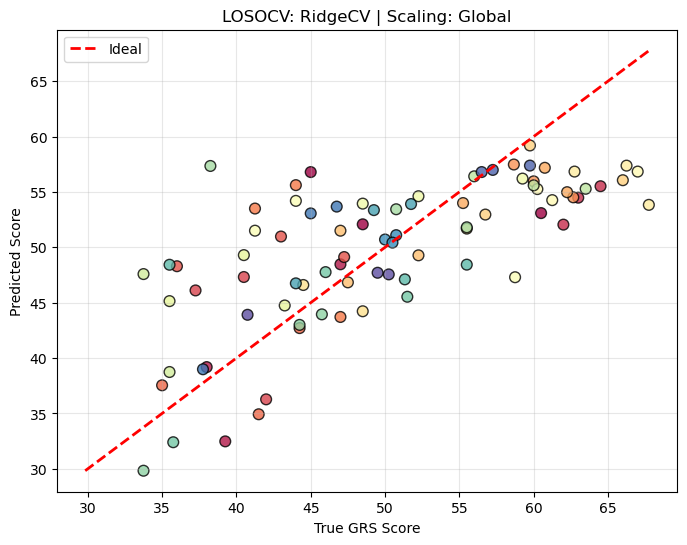

In [74]:
_, _, _ = evaluate_loso_model(df_full_standardized, top_features, model_class=RidgeCV, model_params={'alphas': np.logspace(-2, 1, 20)}, pca_components=[0,2,3], scale_by_case=False)

Final Thesis Narrative

If I were writing this up, I would frame the Final Baseline as The "Two-Factor" Theory of Surgical Skill:

Factor 1: Efficiency (PC1)

Captures speed, path length, economy of motion.

Explains ~49% of the variance.

Factor 2: Bimanual Coordination (Velocity Correlation)

Captures how well the hands work together.

Explains an additional ~4% of unique variance (Partial R 
2
 ).

Task Context (Case Number)

"While task difficulty does shift the baseline scores, we exclude it from the primary model to ensure the metrics remain task-agnostic and robust."

Verdict

You are ready. Drop Step 8 (or keep it as a "secondary analysis" in the discussion), stick to the PC1 + Velocity Corr hybrid, and proceed. This is a very clean, defensible baseline.

In [18]:
# store the dataframe with only the top features
#df_full[['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'velocity_corr'] + top_features].to_csv("data/metrics/top_features_df.csv", index=False)

## **NN Model**



LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.2487 | Test MAE: 8.4920 | Test Corr: -0.6482
Surgeon 2 | Train MAE: 4.4993 | Test MAE: 2.4151 | Test Corr: 0.8542
Surgeon 3 | Train MAE: 4.4779 | Test MAE: 4.9538 | Test Corr: 0.9789
Surgeon 4 | Train MAE: 4.3822 | Test MAE: 6.8630 | Test Corr: -0.4047
Surgeon 5 | Train MAE: 4.4217 | Test MAE: 6.1969 | Test Corr: 0.5390
Surgeon 6 | Train MAE: 4.5582 | Test MAE: 1.2298 | Test Corr: 0.9585
Surgeon 7 | Train MAE: 4.3185 | Test MAE: 7.1236 | Test Corr: -0.8604
Surgeon 9 | Train MAE: 4.4185 | Test MAE: 5.5677 | Test Corr: -0.9150
Surgeon 10 | Train MAE: 4.4903 | Test MAE: 5.0523 | Test Corr: 0.8158
Surgeon 11 | Train MAE: 4.4661 | Test MAE: 3.0403 | Test Corr: -0.0418
Surgeon 12 | Train MAE: 4.4581 | Test MAE: 5.0288 | Test Corr: 0.1529
Surgeon 13 | Train MAE: 4.5282 | Test MAE: 3.3189 | Test Corr: 0.8925
Surgeon 14 | Train MAE: 4.5177 | Test MAE: 6.6225 | Test Corr: -0.2237
Surgeon 15 | Train MAE: 4.5394 | Test MAE: 5.7726 | Test Corr: 0.9463
Surgeon 16 | Train MAE

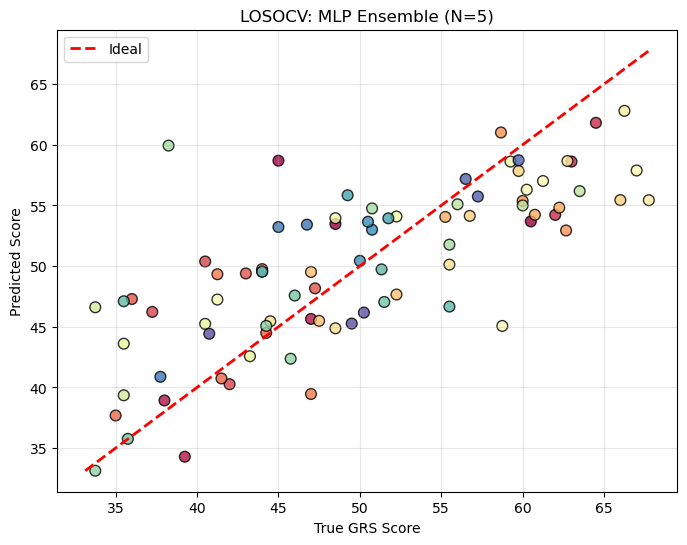

LOSOCV Ensemble Folds:   0%|          | 0/28 [04:26<?, ?it/s]


In [ ]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble

_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_full,
    primary_features=top_features,
    extra_features=['velocity_corr'],
    model_params={'hidden_dim': 16, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)
    


try MLPs with PC1 + velocity_corr + other_features(s)

LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 3.5149 | Test MAE: 8.2409 | Test Corr: -0.2367
Surgeon 2 | Train MAE: 3.7598 | Test MAE: 1.9101 | Test Corr: 0.8871
Surgeon 3 | Train MAE: 3.6250 | Test MAE: 6.1077 | Test Corr: 0.8359
Surgeon 4 | Train MAE: 3.6758 | Test MAE: 5.5547 | Test Corr: 0.0205
Surgeon 5 | Train MAE: 3.6170 | Test MAE: 5.1389 | Test Corr: 0.5726
Surgeon 6 | Train MAE: 3.7523 | Test MAE: 0.9104 | Test Corr: 0.9712
Surgeon 7 | Train MAE: 3.4572 | Test MAE: 9.0874 | Test Corr: -0.8079
Surgeon 9 | Train MAE: 3.6816 | Test MAE: 5.7450 | Test Corr: -0.8461
Surgeon 10 | Train MAE: 3.7761 | Test MAE: 5.2203 | Test Corr: 0.9868
Surgeon 11 | Train MAE: 3.7602 | Test MAE: 2.4812 | Test Corr: -0.0800
Surgeon 12 | Train MAE: 3.8086 | Test MAE: 3.2702 | Test Corr: 0.3286
Surgeon 13 | Train MAE: 3.7568 | Test MAE: 4.0305 | Test Corr: 0.9433
Surgeon 14 | Train MAE: 3.8135 | Test MAE: 7.5073 | Test Corr: -0.9024
Surgeon 15 | Train MAE: 3.8260 | Test MAE: 4.8242 | Test Corr: 0.9995
Surgeon 16 | Train MAE:

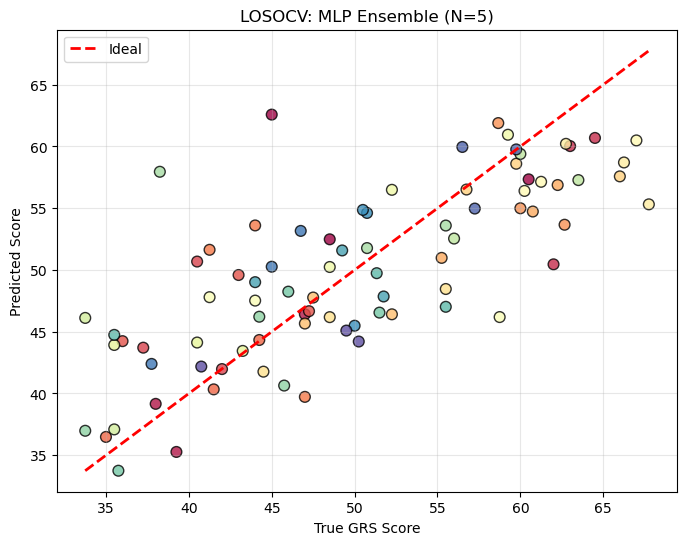

LOSOCV Ensemble Folds:   0%|          | 0/28 [03:24<?, ?it/s]


"\nextra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3']\n\n------- dropout = 0.2 -------\nhidden_dim = 16\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7491 | MAE: 4.7653 | MAE STD: 3.9071 | R2: 0.5617\n\nhidden_dim = 32\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7534 | MAE: 4.6758 | MAE STD: 3.9171 | R2: 0.5706\n\nhidden_dim = 16, n_hidden=2\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7416 | MAE: 4.8548 | MAE STD: 3.7990 | R2: 0.5614\n\n------- dropout = 0.15 -------\nhidden_dim = 24, n_hidden=2\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7546 | MAE: 4.6321 | MAE STD: 3.8108 | R2: 0.5847\n\nhidden_dim = 32, n_hidden=2\n=== LOSOCV Ensemble MLP Results (Global Scaling) ===\nSpearman R: 0.7490 | MAE: 4.6869 | MAE STD: 3.8471 | R2: 0.5756\n\nextra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3', 'interhand_dist_change_rms']\n=== LOSOCV Ensemble MLP Results (Global Scaling) 

In [75]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble

f = 'interhand_dist_change_rms'
_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_full,
    primary_features=top_features,
    extra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3', 'fraction_tracked_Right'],
    model_params={'hidden_dim': 24, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)
"""
extra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3']

------- dropout = 0.2 -------
hidden_dim = 16
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7491 | MAE: 4.7653 | MAE STD: 3.9071 | R2: 0.5617

hidden_dim = 32
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7534 | MAE: 4.6758 | MAE STD: 3.9171 | R2: 0.5706

hidden_dim = 16, n_hidden=2
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7416 | MAE: 4.8548 | MAE STD: 3.7990 | R2: 0.5614

------- dropout = 0.15 -------
hidden_dim = 24, n_hidden=2
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7546 | MAE: 4.6321 | MAE STD: 3.8108 | R2: 0.5847

hidden_dim = 32, n_hidden=2
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7490 | MAE: 4.6869 | MAE STD: 3.8471 | R2: 0.5756

extra_features=['velocity_corr', 'Case_1', 'Case_2', 'Case_3', 'interhand_dist_change_rms']
=== LOSOCV Ensemble MLP Results (Global Scaling) ===
Spearman R: 0.7481 | MAE: 4.8682 | MAE STD: 3.7360 | R2: 0.5654
"""

Evaluating with extra feature: interhand_dist_change_rms


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.1293 | Test MAE: 8.5376 | Test Corr: -0.6334
Surgeon 2 | Train MAE: 4.4093 | Test MAE: 2.3754 | Test Corr: 0.8460
Surgeon 3 | Train MAE: 4.3946 | Test MAE: 5.3697 | Test Corr: 0.9814
Surgeon 4 | Train MAE: 4.2828 | Test MAE: 6.5424 | Test Corr: -0.3929
Surgeon 5 | Train MAE: 4.3278 | Test MAE: 5.5348 | Test Corr: 0.6086
Surgeon 6 | Train MAE: 4.4847 | Test MAE: 1.3083 | Test Corr: 0.9799
Surgeon 7 | Train MAE: 4.2905 | Test MAE: 6.5988 | Test Corr: -0.8624
Surgeon 9 | Train MAE: 4.3560 | Test MAE: 5.0875 | Test Corr: -0.9399
Surgeon 10 | Train MAE: 4.3690 | Test MAE: 5.7167 | Test Corr: 0.9636
Surgeon 11 | Train MAE: 4.4109 | Test MAE: 3.1701 | Test Corr: -0.0331
Surgeon 12 | Train MAE: 4.3868 | Test MAE: 4.6198 | Test Corr: 0.2384
Surgeon 13 | Train MAE: 4.4062 | Test MAE: 3.3220 | Test Corr: 0.8952
Surgeon 14 | Train MAE: 4.4024 | Test MAE: 6.7761 | Test Corr: -0.2179
Surgeon 15 | Train MAE: 4.4152 | Test MAE: 5.3450 | Test Corr: 0.9102
Surgeon 16 | Train MAE

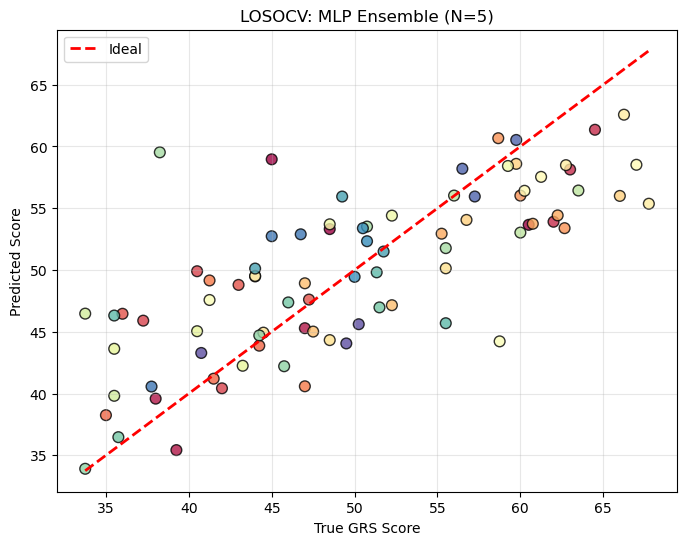

LOSOCV Ensemble Folds:   0%|          | 0/28 [03:09<?, ?it/s]


Evaluating with extra feature: mean_velocity_Left


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.1929 | Test MAE: 8.3071 | Test Corr: -0.5515
Surgeon 2 | Train MAE: 4.4063 | Test MAE: 2.3502 | Test Corr: 0.8616
Surgeon 3 | Train MAE: 4.3635 | Test MAE: 5.6199 | Test Corr: 0.9843
Surgeon 4 | Train MAE: 4.3377 | Test MAE: 6.3238 | Test Corr: -0.3559
Surgeon 5 | Train MAE: 4.3465 | Test MAE: 5.7708 | Test Corr: 0.7119
Surgeon 6 | Train MAE: 4.5133 | Test MAE: 1.2918 | Test Corr: 0.9868
Surgeon 7 | Train MAE: 4.3030 | Test MAE: 6.6114 | Test Corr: -0.8925
Surgeon 9 | Train MAE: 4.2587 | Test MAE: 6.2666 | Test Corr: -0.9228
Surgeon 10 | Train MAE: 4.3306 | Test MAE: 5.4391 | Test Corr: 0.7484
Surgeon 11 | Train MAE: 4.4082 | Test MAE: 3.0458 | Test Corr: 0.0187
Surgeon 12 | Train MAE: 4.4000 | Test MAE: 5.1525 | Test Corr: 0.1057
Surgeon 13 | Train MAE: 4.3675 | Test MAE: 3.3312 | Test Corr: 0.9197
Surgeon 14 | Train MAE: 4.3671 | Test MAE: 8.9511 | Test Corr: -0.2784
Surgeon 15 | Train MAE: 4.3873 | Test MAE: 5.6550 | Test Corr: 0.8961
Surgeon 16 | Train MAE:

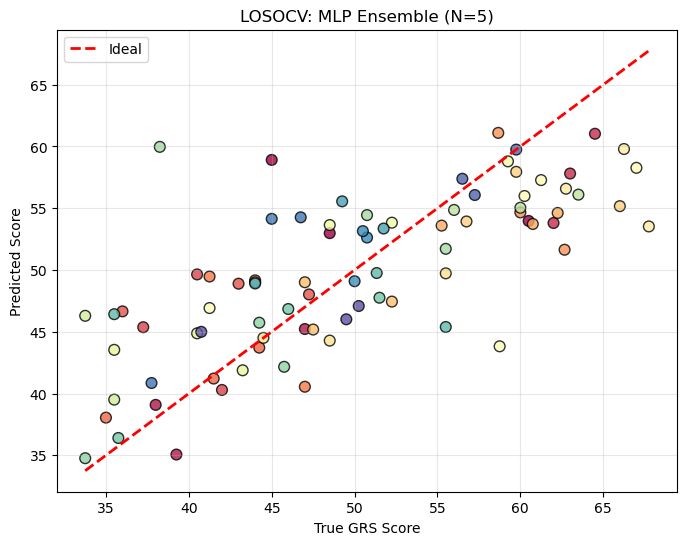

LOSOCV Ensemble Folds:   0%|          | 0/28 [05:07<?, ?it/s]


Evaluating with extra feature: workspace_area_Right


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.1200 | Test MAE: 9.4856 | Test Corr: -0.8649
Surgeon 2 | Train MAE: 4.4019 | Test MAE: 2.2555 | Test Corr: 0.8550
Surgeon 3 | Train MAE: 4.4103 | Test MAE: 5.4604 | Test Corr: 0.9851
Surgeon 4 | Train MAE: 4.3333 | Test MAE: 6.9609 | Test Corr: -0.4262
Surgeon 5 | Train MAE: 4.3624 | Test MAE: 5.8950 | Test Corr: 0.4020
Surgeon 6 | Train MAE: 4.4768 | Test MAE: 1.3369 | Test Corr: 0.9998
Surgeon 7 | Train MAE: 4.2616 | Test MAE: 7.0858 | Test Corr: -0.8858
Surgeon 9 | Train MAE: 4.3530 | Test MAE: 5.4160 | Test Corr: -0.9231
Surgeon 10 | Train MAE: 4.3807 | Test MAE: 5.2010 | Test Corr: 0.9791
Surgeon 11 | Train MAE: 4.4016 | Test MAE: 3.1853 | Test Corr: -0.0249
Surgeon 12 | Train MAE: 4.3942 | Test MAE: 4.9709 | Test Corr: 0.0710
Surgeon 13 | Train MAE: 4.4177 | Test MAE: 3.3305 | Test Corr: 0.9319
Surgeon 14 | Train MAE: 4.3885 | Test MAE: 6.9455 | Test Corr: -0.2619
Surgeon 15 | Train MAE: 4.4207 | Test MAE: 5.7253 | Test Corr: 0.9387
Surgeon 16 | Train MAE

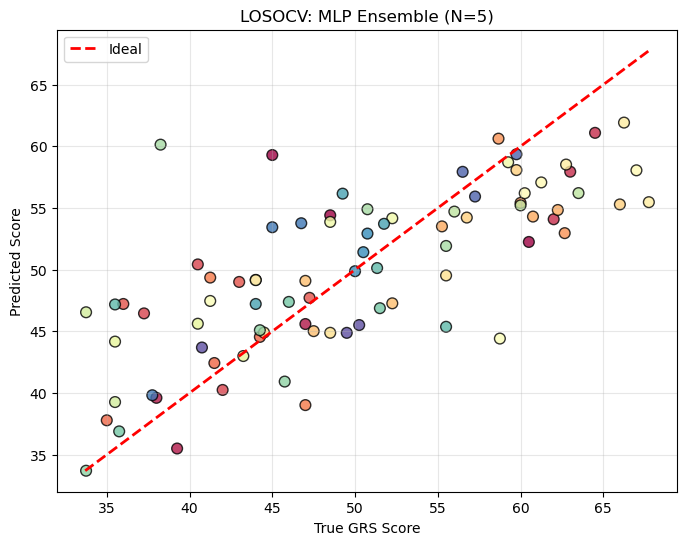

LOSOCV Ensemble Folds:   0%|          | 0/28 [05:43<?, ?it/s]


Evaluating with extra feature: pose_variability_Right


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.2656 | Test MAE: 8.1652 | Test Corr: -0.5669
Surgeon 2 | Train MAE: 4.3943 | Test MAE: 2.7414 | Test Corr: 0.8537
Surgeon 3 | Train MAE: 4.3852 | Test MAE: 4.7732 | Test Corr: 0.9498
Surgeon 4 | Train MAE: 4.3124 | Test MAE: 6.4754 | Test Corr: -0.1858
Surgeon 5 | Train MAE: 4.3570 | Test MAE: 7.3681 | Test Corr: 0.6693
Surgeon 6 | Train MAE: 4.5211 | Test MAE: 1.7610 | Test Corr: 0.9186
Surgeon 7 | Train MAE: 4.2856 | Test MAE: 6.3429 | Test Corr: -0.8745
Surgeon 9 | Train MAE: 4.3528 | Test MAE: 5.0855 | Test Corr: -0.9285
Surgeon 10 | Train MAE: 4.3565 | Test MAE: 6.0998 | Test Corr: -0.4073
Surgeon 11 | Train MAE: 4.4576 | Test MAE: 2.1437 | Test Corr: -0.7725
Surgeon 12 | Train MAE: 4.4305 | Test MAE: 5.3215 | Test Corr: 0.2153
Surgeon 13 | Train MAE: 4.4417 | Test MAE: 3.1095 | Test Corr: 0.8631
Surgeon 14 | Train MAE: 4.4274 | Test MAE: 6.7752 | Test Corr: 0.0880
Surgeon 15 | Train MAE: 4.4189 | Test MAE: 6.6340 | Test Corr: 0.2708
Surgeon 16 | Train MAE

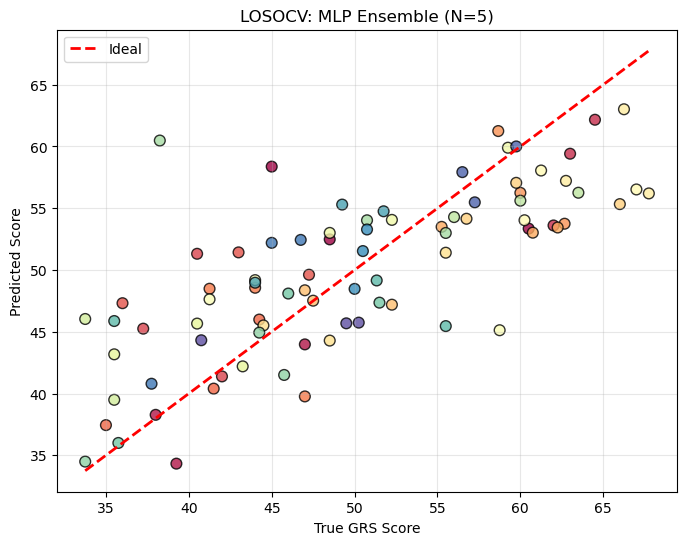

LOSOCV Ensemble Folds:   0%|          | 0/28 [05:03<?, ?it/s]


Evaluating with extra feature: fraction_tracked_Right


LOSOCV Ensemble Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Surgeon 1 | Train MAE: 4.1285 | Test MAE: 8.4787 | Test Corr: -0.5644
Surgeon 2 | Train MAE: 4.3972 | Test MAE: 1.5993 | Test Corr: 0.9641
Surgeon 3 | Train MAE: 4.3136 | Test MAE: 6.0870 | Test Corr: 0.9973
Surgeon 4 | Train MAE: 4.2409 | Test MAE: 6.0621 | Test Corr: -0.2111
Surgeon 5 | Train MAE: 4.2954 | Test MAE: 5.5308 | Test Corr: 0.6023
Surgeon 6 | Train MAE: 4.4322 | Test MAE: 1.0959 | Test Corr: 0.9698
Surgeon 7 | Train MAE: 4.1768 | Test MAE: 7.1683 | Test Corr: -0.8585
Surgeon 9 | Train MAE: 4.2772 | Test MAE: 5.6275 | Test Corr: -0.8987
Surgeon 10 | Train MAE: 4.3015 | Test MAE: 5.5558 | Test Corr: 0.9202
Surgeon 11 | Train MAE: 4.3699 | Test MAE: 2.8533 | Test Corr: -0.4404
Surgeon 12 | Train MAE: 4.3303 | Test MAE: 4.3758 | Test Corr: 0.3009
Surgeon 13 | Train MAE: 4.3570 | Test MAE: 3.5626 | Test Corr: 0.9998
Surgeon 14 | Train MAE: 4.3190 | Test MAE: 8.0254 | Test Corr: -0.8876
Surgeon 15 | Train MAE: 4.2881 | Test MAE: 4.0244 | Test Corr: 0.9972
Surgeon 16 | Train MAE

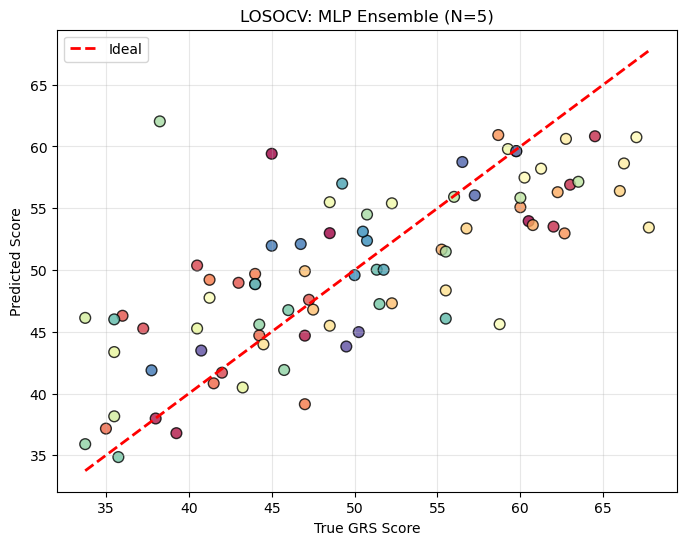

LOSOCV Ensemble Folds:   0%|          | 0/28 [04:57<?, ?it/s]


: 

: 

In [ ]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble
features_to_try = ['interhand_dist_change_rms', 'mean_velocity_Left', 'workspace_area_Right', 'pose_variability_Right', 'fraction_tracked_Right']

for f in features_to_try:
    print(f"Evaluating with extra feature: {f}")
    _, _, _ = evaluate_loso_mlp_ensemble(
        model_class=PyTorchMLPEnsemble,
        df=df_full,
        primary_features=top_features,
        extra_features=['velocity_corr', f],
        model_params={'hidden_dim': 16, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
        pca_components=[0],
        print_fold_metrics=True
    )